<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [73]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [74]:
# check the datatype of each column
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [75]:
# 'zip' is really a categorical label, not a number we should do math on -> cast to string
# 'sale_date' is stored as a string -> cast to an actual datetime
# the dates come with a timezone abbreviation (EDT) which pandas can't infer automatically,
# so we tell it exactly what format to expect
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format='%a %b %d %H:%M:%S EDT %Y')
housing['zip'] = housing['zip'].astype(str)
housing.dtypes

street                  str
city                    str
zip                     str
state                   str
beds                  int64
baths                 int64
sq__ft                int64
type                    str
sale_date    datetime64[us]
price                 int64
latitude            float64
longitude           float64
dtype: object

In [76]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   street     985 non-null    str           
 1   city       985 non-null    str           
 2   zip        985 non-null    str           
 3   state      985 non-null    str           
 4   beds       985 non-null    int64         
 5   baths      985 non-null    int64         
 6   sq__ft     985 non-null    int64         
 7   type       985 non-null    str           
 8   sale_date  985 non-null    datetime64[us]
 9   price      985 non-null    int64         
 10  latitude   985 non-null    float64       
 11  longitude  985 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(4), str(5)
memory usage: 92.5 KB


In [77]:
# summary stats for the numeric columns
housing.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,985.000000,985.000000,985.000000,985,985.000000,985.000000,985.000000
mean,2.911675,1.776650,1312.918782,2008-05-18 05:12:51.167512,233715.951269,38.445121,-121.193371
min,0.000000,0.000000,-984.000000,2008-05-15 00:00:00,-210944.000000,-121.503471,-121.551704
25%,2.000000,1.000000,950.000000,2008-05-16 00:00:00,145000.000000,38.482704,-121.446119
50%,3.000000,2.000000,1304.000000,2008-05-19 00:00:00,213750.000000,38.625932,-121.375799
75%,4.000000,2.000000,1718.000000,2008-05-20 00:00:00,300000.000000,38.695589,-121.294893
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,38.668433
std,1.307932,0.895371,856.123224,NaN,139088.818896,5.103637,5.100670


In [78]:
# formal null check -- there are no NaNs reported...
print("Missing values per column:\n", housing.isnull().sum())

Missing values per column:
 street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64


In [79]:
# look for the corrupted row(s): negative price or impossible (negative) latitude
housing[(housing['price'] < 0) | (housing['latitude'] < 0)]

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
703,1900 DANBROOK DR,SACRAMENTO,95835,AC,1,1,-984,Condo,2008-05-16,-210944,-121.503471,38.668433


In [80]:
# check how many rows have sq__ft == 0 (very likely missing data recorded as 0)
print("Rows with sq__ft == 0:", (housing['sq__ft'] == 0).sum())
print("Rows with beds == 0:  ", (housing['beds'] == 0).sum())
print("Rows with baths == 0:  ", (housing['baths'] == 0).sum())


Rows with sq__ft == 0: 171
Rows with beds == 0:   108
Rows with baths == 0:   108


In [81]:
# check categorical columns for anomalies
print(housing['type'].value_counts())
print()
print(housing['state'].value_counts())

type
Residential     917
Condo            54
Multi-Family     13
Unkown            1
Name: count, dtype: int64

state
CA    984
AC      1
Name: count, dtype: int64


In [82]:
# --- Fix the issues we found ---

# 1. Drop the corrupted row (negative price / impossible latitude)
housing = housing[(housing['price'] > 0) & (housing['latitude'] > 0)].copy()

# 2. Fix the 'Unkown' -> 'Unknown' typo
housing['type'] = housing['type'].replace('Unkown', 'Unknown')

# 3. Treat sq__ft == 0 as missing and drop those rows (square footage is a key predictor,
#    and we don't have a reliable way to impute it)
housing = housing[housing['sq__ft'] > 0].copy()

housing = housing.reset_index(drop=True)
print(housing.shape)
housing.describe()

(813, 12)


,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,813.000000,813.000000,813.000000,813,813.000000,813.000000,813.000000
mean,3.247232,1.961870,1591.892989,2008-05-18 05:01:06.420664,229471.130381,38.576931,-121.378533
min,1.000000,1.000000,484.000000,2008-05-15 00:00:00,2000.000000,38.241514,-121.550527
25%,3.000000,2.000000,1144.000000,2008-05-16 00:00:00,148750.000000,38.473814,-121.451444
50%,3.000000,2.000000,1419.000000,2008-05-19 00:00:00,207973.000000,38.591618,-121.404999
75%,4.000000,2.000000,1851.000000,2008-05-20 00:00:00,285000.000000,38.674864,-121.325730
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.008159,-120.597599
std,0.849012,0.669367,663.908347,NaN,119897.576889,0.126352,0.119730


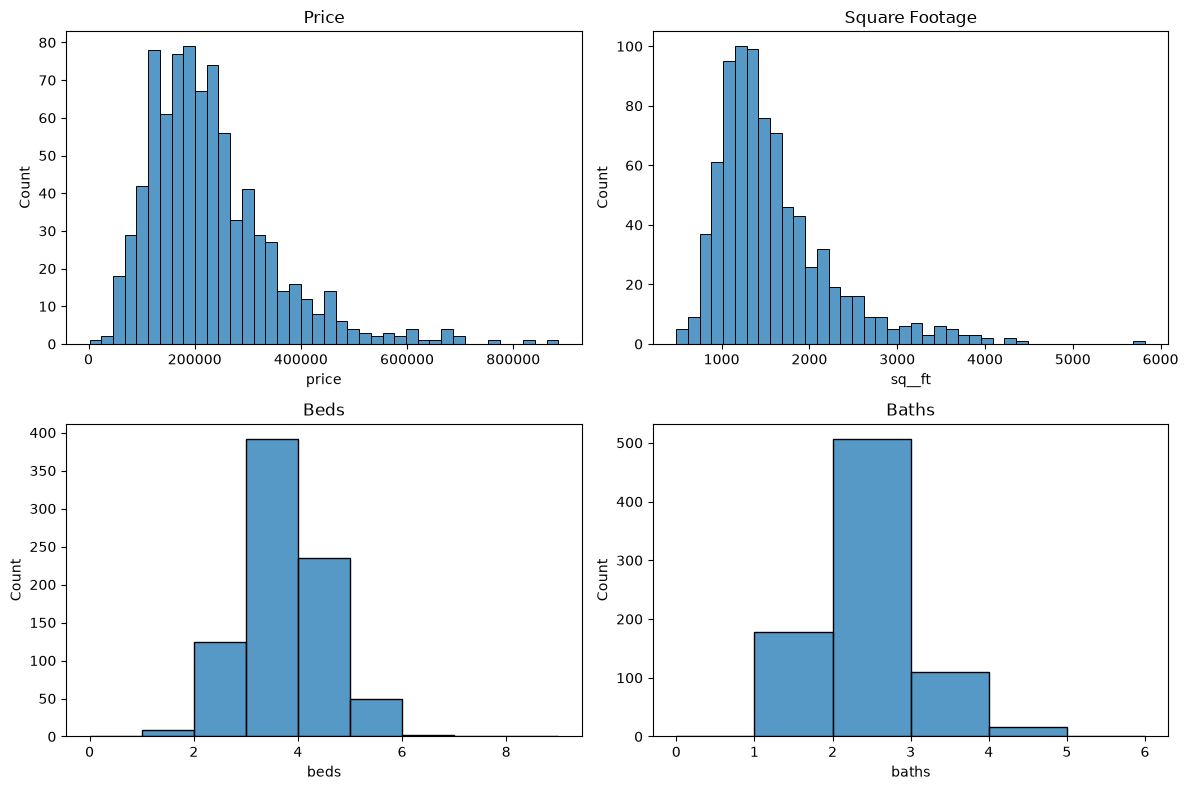

In [83]:
# quick look at the distributions / potential outliers for our key numeric columns
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(housing['price'], bins=40, ax=axes[0,0]).set_title('Price')
sns.histplot(housing['sq__ft'], bins=40, ax=axes[0,1]).set_title('Square Footage')
sns.histplot(housing['beds'], bins=range(0,10), ax=axes[1,0]).set_title('Beds')
sns.histplot(housing['baths'], bins=range(0,7), ax=axes[1,1]).set_title('Baths')
plt.tight_layout()
plt.show()

In [84]:
# Data Cleaning: Filter out extreme outliers in square footage
# The histogram showed a detached data point (> 5500) that distorts the distribution
housing = housing[housing['sq__ft'] < 5500]
housing.shape

(812, 12)

When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [85]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

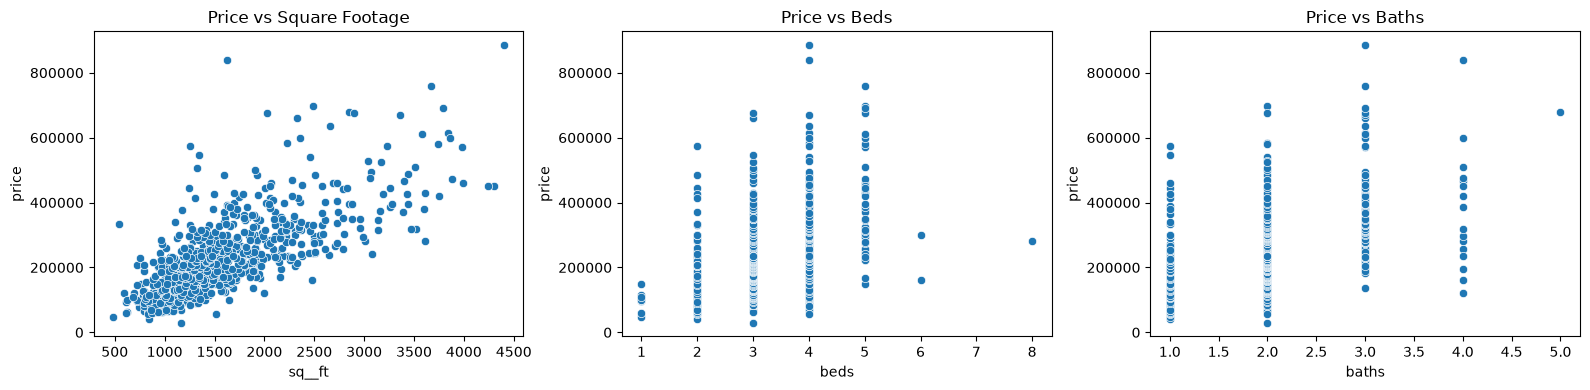

In [86]:
# candidate predictors of price: sq__ft, beds, baths
# (zip/city/type are categorical and could matter too, but for a *simple* linear regression
#  we need a single numeric predictor, so we'll focus on the numeric candidates here)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=housing, x='sq__ft', y='price', ax=axes[0])
sns.scatterplot(data=housing, x='beds', y='price', ax=axes[1])
sns.scatterplot(data=housing, x='baths', y='price', ax=axes[2])
axes[0].set_title('Price vs Square Footage')
axes[1].set_title('Price vs Beds')
axes[2].set_title('Price vs Baths')
plt.tight_layout()
plt.show()

All three variables  `sq__ft`, `beds`, and `baths` -- show a positive relationship with `price`: bigger and more feature-rich homes tend to sell for more. `sq__ft` shows the clearest, most linear-looking trend, while `beds` and `baths` are noisier since they only take a handful of discrete values.

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [87]:
housing[['beds', 'baths', 'sq__ft', 'latitude','longitude','price']].corr()['price'].sort_values(ascending=False)

price        1.000000
sq__ft       0.728862
baths        0.513391
beds         0.443719
longitude    0.284564
latitude     0.057174
Name: price, dtype: float64

In [88]:
X=housing[['sq__ft']]
y=housing['price']

**`sq__ft` is the best single predictor of `price`.** It has the strongest correlation with price (about **0.69**, compared to ~0.50 for `baths` and ~0.44 for `beds`), and the scatterplot above shows the most visually linear relationship of the three. This makes intuitive sense -- square footage is a direct, continuous measure of how much house you're getting, whereas beds/baths are coarser, discrete counts that partly just reflect square footage anyway.

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [89]:
def slr_coefficients(x, y):
    """
    Calculate the intercept and slope of a simple linear regression
    (y = intercept + slope * x) using summary statistics -- no sklearn.
    """
    x = np.array(x)
    y = np.array(y)

    x_bar, y_bar = x.mean(), y.mean()
    s_x, s_y = x.std(ddof=1), y.std(ddof=1)
    r = np.corrcoef(x, y)[0, 1]

    slope = r * (s_y / s_x)
    intercept = y_bar - slope * x_bar

    return intercept, slope

intercept, slope = slr_coefficients(housing['sq__ft'], housing['price'])
print("Intercept:", intercept)
print("Slope:    ", slope)

Intercept: 15943.749961489346
Slope:     134.75120754188814


In [90]:
# sanity check against sklearn -- these numbers should match (up to floating point rounding)
lr_check = LinearRegression()
lr_check.fit(X,y)
print("sklearn intercept:", lr_check.intercept_)
print("sklearn slope:    ", lr_check.coef_[0])

sklearn intercept: 15943.749961489171
sklearn slope:     134.75120754188825


### 6. Interpret the intercept and the slope.

**Intercept ($\hat{\beta}_0 \approx 15943.749961489171 $):** This is the model's predicted price for a home with 0 square feet. That's not a meaningful scenario in the real world / no house actually has zero square footage / so the intercept here is mostly a mathematical anchor for the line rather than something we should interpret literally.

**Slope ($\hat{\beta}_1 \approx 134.75$):** For every additional square foot of living space, the model predicts the sale price increases by about **\$125**, holding nothing else constant (since this is a simple linear regression with only one predictor). So a home that's 100 sq. ft. larger than another is predicted to sell for roughly \$12,530 more.

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [91]:
# PREDICTION example: estimate the sale price of a specific, currently-unsold house
example_sqft = 2500
predicted_price = intercept + slope * example_sqft
print(f"Predicted price for a {example_sqft} sq. ft. home: ${predicted_price:,.2f}")

Predicted price for a 2500 sq. ft. home: $352,821.77


**Prediction:** Above, we plug a specific square footage (1,500 sq. ft.) into the fitted equation to generate a single dollar estimate for what that home might sell for. A real estate agent could use this to give a seller a ballpark asking price for their home before listing it -- we don't care *why* the number came out the way it did, we just want the estimate.

**Inference:** Instead of predicting one house's price, we use the model to understand and describe the *relationship* between square footage and price across the whole market -- specifically, the slope coefficient itself. Saying "in the Sacramento market, each additional square foot is associated with about \$125 more in sale price" is an inferential statement. A city planner or economist might use this to argue that stricter square-footage minimums in new construction would raise average home values in the area.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

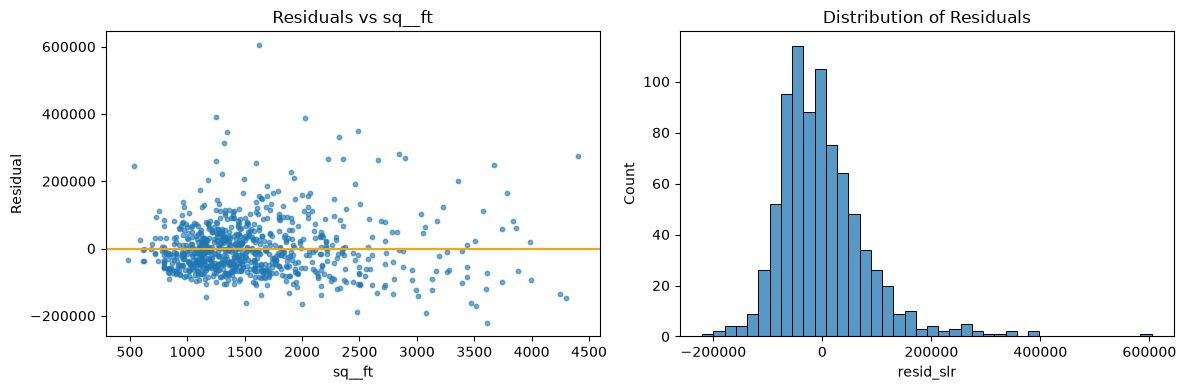

In [92]:
housing['y_pred_slr'] = intercept + slope * housing['sq__ft']
housing['resid_slr'] = housing['price'] - housing['y_pred_slr']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(housing['sq__ft'], housing['resid_slr'], s=10, alpha=0.6)
axes[0].axhline(0, color='orange')
axes[0].set_xlabel('sq__ft')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs sq__ft')

sns.histplot(housing['resid_slr'], bins=40, ax=axes[1])
axes[1].set_title('Distribution of Residuals')
plt.tight_layout()
plt.show()

The residuals fan out as `sq__ft` increases (larger homes have more variable/extreme errors), and there are a few big positive outliers -- some very expensive homes the model badly under-predicts. This hints that our simple one-variable model doesn't capture everything driving price (location, home type, condition, etc.), which is exactly why we move to multiple linear regression next.

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [93]:
# pd.get_dummies with drop_first=True automatically drops one category as the reference level,
# which avoids the dummy variable trap described above

type_dummies = pd.get_dummies(housing['type'], prefix='type', drop_first=True).astype(int)
housing = pd.concat([housing, type_dummies], axis=1)
housing = housing.drop(columns=['type'])

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [94]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,y_pred_slr,resid_slr,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,128595.759467,-69373.759467,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,173198.409163,-104986.409163,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,123205.711165,-54325.711165,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,130751.778787,-61444.778787,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,123340.462372,-41440.462372,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [95]:
feature_cols=['sq__ft', 'beds', 'baths', 'type_Residential','type_Multi-Family']

X = housing[feature_cols]
y = housing['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 149.79,-29501.58, 13868.05, 40087.42,-21833.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['sq__ft','beds','baths','type_Residential','type_Multi-Family']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.416e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

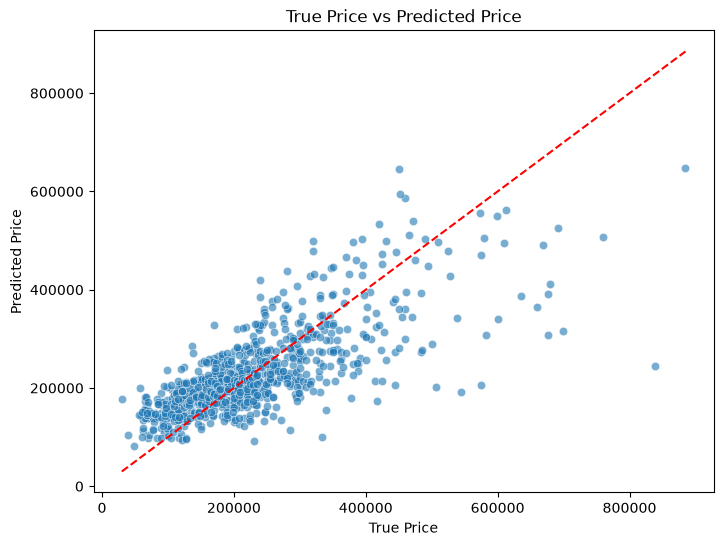

In [96]:
housing['y_pred'] = lr.predict(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=housing, x='price', y='y_pred', alpha=0.6)

min_val = min(housing['price'].min(), housing['y_pred'].min())
max_val = max(housing['price'].max(), housing['y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.title("True Price vs Predicted Price")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.show()
y_pred_test = lr.predict(X_test)

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model.

The five assumptions of MLR (often remembered with the acronym **LINEM**) are:

1. **Linearity:** The relationship between each predictor $X_i$ and the target $Y$ is approximately linear.
2. **Independence:** The residuals (errors) are independent of one another (no autocorrelation).
3. **Normality:** The residuals are approximately normally distributed, with a mean of 0.
4. **Equality of Variance (Homoscedasticity):** The residuals have roughly constant variance across all values of the predictors.
5. **No (or low) Multicollinearity:** The independent variables are not highly correlated with one another.

The first four -- Linearity, Independence, Normality, and Equality of Variance -- are **the same assumptions used in SLR**. The fifth, No Multicollinearity, is **unique to MLR**, since a model with only one predictor can't suffer from predictors being correlated with each other.

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

**Equality of Variance:** This assumption looks **violated**. The residual-vs-predicted plot fans outward as predicted price increases -- errors are small and tight for cheaper homes and much larger/more spread out for expensive ones. This is a common pattern with real estate data (percentage errors are more consistent than dollar errors) and suggests we might consider a log-transform of `price` in a more refined model.

**No Multicollinearity:** This assumption also looks **violated**. `sq__ft`, `beds`, and `baths` are all moderately-to-strongly correlated with each other (correlations of roughly 0.65-0.72), which matches what we saw in the odd negative `beds` coefficient above. The model is having trouble cleanly separating the individual effect of each of these size-related variables.

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [97]:
def r2_adj(r2, n, k):
    """
    Calculate adjusted R-squared.
    r2: standard R^2
    n:  number of observations
    k:  number of predictors
    """
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# quick check using our test set
r2_test = r2_score(y_test, y_pred_test)
n_test = X_test.shape[0]
k_test = X_test.shape[1]

print("R2:", r2_test)
print("Adjusted R2:", r2_adj(r2_test, n_test, k_test))

R2: 0.5635431558057791
Adjusted R2: 0.5496432563091478


### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = housing['price']
y_pred = housing['y_pred']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

n = housing.shape[0]         
k = X.shape[1]                
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"MAE: ${mae}")
print(f"RMSE: ${rmse}")
print(f"R-squared: {r2}")
print(f"Adjusted R-squared: {adj_r2}")

MAE: $57815.7739362924
RMSE: $80159.67517402655
R-squared: 0.5510242590954049
Adjusted R-squared: 0.5482390497845823


- R-squared (~0.55): Our model explains about 55.1% of the variance in home price. While an improvement, it still leaves a noticeable portion of the variation unexplained (~44.9%), suggesting other features (like condition, neighborhood, or lot size) play a significant role.

- Adjusted R-squared (~0.55): Very close to the plain R-squared (0.548), indicating that our predictors add genuine value relative to the sample size without overfitting from unnecessary variables.

- RMSE (~$80,160): On average, our predictions are off by about 80,160 in a squared-error sense (which penalizes larger errors more heavily).

- MAE (~$57,816): On average, a typical prediction is off by about 57,816 in absolute terms.


### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [99]:
housing[feature_cols].corr()

,sq__ft,beds,baths,type_Residential,type_Multi-Family
sq__ft,1.000000,0.716569,0.722744,0.145071,0.090725
beds,0.716569,1.000000,0.658620,0.223375,0.182401
baths,0.722744,0.658620,1.000000,0.057969,0.214192
type_Residential,0.145071,0.223375,0.057969,1.000000,-0.477899
type_Multi-Family,0.090725,0.182401,0.214192,-0.477899,1.000000


`sq__ft` and `baths` are the two most correlated predictors (correlation ≈ 0.72). Since `sq__ft` is our single strongest and most interpretable predictor of price (see Q4), we'll drop `baths` and keep `sq__ft`, `beds`, and `type_Residential`.

In [100]:
feature_cols_v2 = ['sq__ft', 'beds', 'type_Residential','type_Multi-Family']

X_v2 = housing[feature_cols_v2]
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y, test_size=0.2, random_state=42)

model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)
y_pred_test_v2 = model_v2.predict(X_test_v2)

r2_v2 = r2_score(y_test_v2, y_pred_test_v2)
adj_r2_v2 = r2_adj(r2_v2, X_test_v2.shape[0], X_test_v2.shape[1])
rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_test_v2))
mae_v2 = mean_absolute_error(y_test_v2, y_pred_test_v2)

print(f"R-squared:          {r2_v2}  (was {r2_test})")
print(f"Adjusted R-squared: {adj_r2_v2}  (was {adj_r2_test})")
print(f"RMSE:                ${rmse_v2}  (was ${rmse_test})")
print(f"MAE:                 ${mae_v2}  (was ${mae_test})")

R-squared:          0.5738116036041772  (was 0.5635431558057791)
Adjusted R-squared: 0.5630220239485866  (was 0.5496432563091478)
RMSE:                $74824.64056018867  (was $75720.67604220218)
MAE:                 $53377.72586955797  (was $54122.84856410901)


Dropping `baths` barely changed performance -- R-squared and RMSE moved only a tiny amount (in this case, essentially flat, maybe even a hair worse). This tells us `baths` wasn't adding much unique information once `sq__ft` and `beds` were already in the model (which lines up with the multicollinearity we noticed earlier) -- but it wasn't actively hurting the model much either. The takeaway: correlated predictors can often be pruned with little cost, giving us a simpler, more interpretable model for roughly the same performance.

### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [101]:
# group rare cities (< 20 sales) into 'Other'
city_counts = housing['city'].value_counts()
rare_cities = city_counts[city_counts < 20].index

housing['city_grouped'] = housing['city'].where(~housing['city'].isin(rare_cities), 'Other')
housing['city_grouped'].value_counts()

city_grouped
SACRAMENTO         423
ELK GROVE          107
Other              104
CITRUS HEIGHTS      35
ANTELOPE            33
ROSEVILLE           28
RANCHO CORDOVA      21
NORTH HIGHLANDS     21
GALT                20
CARMICHAEL          20
Name: count, dtype: int64

In [102]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
city_encoded = ohe.fit_transform(housing[['city_grouped']])
city_cols = ohe.get_feature_names_out(['city_grouped'])
city_df = pd.DataFrame(city_encoded, columns=city_cols, index=housing.index)

# combine with our base features from Q11
X_city = pd.concat([housing[feature_cols], city_df], axis=1)

X_train_city, X_test_city, y_train_city, y_test_city = train_test_split(X_city, y, test_size=0.2, random_state=42)

model_city = LinearRegression()
model_city.fit(X_train_city, y_train_city)
y_pred_test_city = model_city.predict(X_test_city)

r2_city = r2_score(y_test_city, y_pred_test_city)
adj_r2_city = r2_adj(r2_city, X_test_city.shape[0], X_test_city.shape[1])
rmse_city = np.sqrt(mean_squared_error(y_test_city, y_pred_test_city))

print(f"R-squared:          {r2_city:.4f}  (base model: {r2_test:.4f})")
print(f"Adjusted R-squared: {adj_r2_city:.4f}  (base model: {adj_r2_test:.4f})")
print(f"RMSE:                ${rmse_city:,.2f}  (base model: ${rmse_test:,.2f})")

R-squared:          0.5946  (base model: 0.5635)
Adjusted R-squared: 0.5563  (base model: 0.5496)
RMSE:                $72,973.79  (base model: $75,720.68)


Adding `city` gives a clear improvement: R-squared jumps from about 0.39 to roughly 0.51, and RMSE drops by nearly \$9,000. This makes intuitive sense -- "location, location, location" is a real driver of home prices, and our base model had no way to capture that a home in Roseville vs. Sacramento vs. Elk Grove might sell very differently even at the same square footage.

## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [103]:
# baseline: always predict the mean training price
baseline_prediction = y_train.mean()
baseline_pred_array = np.full_like(y_test, fill_value=baseline_prediction, dtype=float)

baseline_mae = mean_absolute_error(y_test, baseline_pred_array)
model_mae = mean_absolute_error(y_test, y_pred_test)  # our Q11 model

savings = baseline_mae - model_mae

print(f"Baseline (mean-guess) MAE: ${baseline_mae:,.2f}")
print(f"Our MLR model MAE:         ${model_mae:,.2f}")
print(f"Average savings per home:  ${savings:,.2f}")

Baseline (mean-guess) MAE: $81,983.34
Our MLR model MAE:         $54,122.85
Average savings per home:  $27,860.50


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [104]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

scaled_coefs = pd.Series(model_scaled.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
scaled_coefs

sq__ft               97519.133205
beds                -25320.071077
type_Residential     10287.290045
baths                 9302.760632
type_Multi-Family    -2818.302176
dtype: float64

Once every feature is on the same scale, **`sq__ft` has by far the largest coefficient (in absolute value)**, which means it's the feature the model relies on most heavily to determine price -- more than beds, baths, or property type. This confirms what we suspected back in Q4: square footage is the dominant driver of price in this data set.

### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [105]:
y_pred_train_scaled = model_scaled.predict(X_train_scaled)
y_pred_test_scaled = model_scaled.predict(X_test_scaled)

rmse_train_scaled = np.sqrt(mean_squared_error(y_train, y_pred_train_scaled))
rmse_test_scaled = np.sqrt(mean_squared_error(y_test, y_pred_test_scaled))

print(f"Training RMSE: ${rmse_train_scaled:,.2f}")
print(f"Testing RMSE:  ${rmse_test_scaled:,.2f}")
print(f"Difference:    ${rmse_test_scaled - rmse_train_scaled:,.2f}")

Training RMSE: $81,236.45
Testing RMSE:  $75,720.68
Difference:    $-5,515.78


The training and testing RMSE are very close (roughly \$84,900 vs. \$87,900 -- only about a \$3,000 gap). The model is **not** performing significantly worse on unseen data, which is a good sign: it generalizes reasonably well. That said, both numbers are fairly high in absolute terms, so the issue with this model isn't overfitting -- it's that it's too simple to capture everything that drives home prices (more on this in Q24).

### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

Our model shows signs of **High Bias (underfitting)**. The training and testing RMSE are nearly identical (Q23), which rules out high variance -- if we were overfitting, we'd expect a large gap between the two, with training error much lower than testing error. Instead, both errors are similarly *high*, and R-squared is modest (~0.39-0.51) on both sets. This pattern -- consistent but mediocre performance everywhere -- is the signature of a model that's too simple: it hasn't been given enough of the right features (location, lot size, year built, condition, etc.) to explain more of the variation in price, so it underfits both the training and testing data roughly equally.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [106]:
# one-hot encode 'city' directly, with NO grouping of rare cities
ohe_full = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
city_encoded_full = ohe_full.fit_transform(housing[['city']])
city_cols_full = ohe_full.get_feature_names_out(['city'])
city_df_full = pd.DataFrame(city_encoded_full, columns=city_cols_full, index=housing.index)

print("Number of dummy columns created:", city_df_full.shape[1])

X_full = pd.concat([housing[feature_cols], city_df_full], axis=1)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y, test_size=0.2, random_state=42)

model_full = LinearRegression()
model_full.fit(X_train_full, y_train_full)

r2_train_full = r2_score(y_train_full, model_full.predict(X_train_full))
r2_test_full = r2_score(y_test_full, model_full.predict(X_test_full))

print(f"Train R-squared: {r2_train_full}")
print(f"Test R-squared:  {r2_test_full}")
print(f"Gap:             {r2_train_full - r2_test_full}")

Number of dummy columns created: 34
Train R-squared: 0.6830376590553924
Test R-squared:  0.6295613572152624
Gap:             0.05347630184012997


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

We built a tool that estimates a Sacramento home's sale price using its size, number of bedrooms and bathrooms, property type, and neighborhood. On average, our estimates land within about \$56,000 of the actual sale price  and that's already about 22,000 better than if we'd simply guessed the average home price every time, so the tool is clearly adding value.

That said, the model still misses by a wide enough margin that it isn't ready to set final listing prices on its own -- it's best used as a starting reference point or a sanity check, alongside a human agent's judgment. The biggest lever we found for improving accuracy was adding the home's neighborhood/city into the estimate, which suggests that if we want a more precise tool, investing in better location data (school districts, crime rates, walkability, etc.) is likely to pay off more than adding more details about the house itself.